# Candidate validation on real data (Catalog 2)

Injection-recovery (`03_injection_recovery_cat2.ipynb`) established the SENSITIVITY of the
candidate detector: subspace_max recovers point, local, subspace and contextual anomalies at
low strength, and CBLOF uniquely recovers a resolvable collective anomaly that every other
method misses. Sensitivity alone is not sufficient. A detector that ranks everything as
anomalous would recover injected anomalies perfectly while being useless on real data.

This notebook tests the missing half, SPECIFICITY, on the real Catalog 2 bursts, and produces
the candidate shortlist. The concern is specific to subspace_max: it scores a burst by the
MAXIMUM rank it attains across 20 random feature-subspaces, so a burst that looks unusual in
any one subspace scores high. That is sensitive but potentially low-precision.

Three diagnostics, each with a defined failure signature:

- **Score concentration.** Sorted anomaly scores per method. A discriminating method has a
  short, separated tail (a knee: a few high scores, then a drop to the bulk). A flooding
  method has a smooth ramp with no separation. Failure signature: no knee.
- **Stability across random seeds.** subspace_max is re-scored under several seeds (different
  random subspaces). The top-ranked real bursts are compared by Jaccard overlap. A
  signal-driven detector returns nearly the same top list every time; a noise-driven one
  returns a different list each seed. Failure signature: low overlap. LOF (deterministic) is
  the trivially-stable reference.
- **Cross-method agreement.** Real bursts ranked highly by several methods of different
  inductive bias are robust candidates; bursts unique to subspace_max and unstable are the
  flood signature. The robust set is the shortlist carried forward.

If subspace_max passes concentration and stability, it is adopted for the real hunt. If it
floods, it is rejected despite its recovery and the set falls back to CBLOF plus LOF/kNN. The
shortlist this notebook produces then goes to artifact rejection (fit-error columns and
quality flags), which is the next step and uses the raw catalogue, not the scaled features.

## Setup: load the real cleaned features

In [1]:
import sys
from pathlib import Path

PROJECT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT / 'src'))

import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

scaled = pd.read_csv(PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_features_scaled.csv')
scaled['is_repeater'] = scaled['is_repeater'].astype(str).str.lower() == 'true'
id_cols = ['tns_name', 'sub_num', 'is_repeater', 'repeater_name', 'catalog1_flag']
feature_cols = [c for c in scaled.columns if c not in id_cols]
X = scaled[feature_cols].values
ids = scaled[['tns_name', 'sub_num', 'is_repeater']].reset_index(drop=True)

print(f'Loaded {len(scaled)} real sub-burst rows, {len(feature_cols)} features')

Loaded 4109 real sub-burst rows, 8 features


## Candidate scorers

The candidate set from injection-recovery is subspace_max and CBLOF; LOF and kNN are
comparators. The scorers are imported from `src/frb_anomaly/methods.py` (extracted so they can
be unit-tested); each returns a per-burst score with higher = more anomalous, matching
`02_methods_cat2.ipynb`. The subspace scorer takes an explicit seed and aggregation mode so the
stability test can vary the random subspaces.

In [2]:
# The scorers are defined in src/frb_anomaly/methods.py so they can be unit-tested. Each
# returns a per-burst score with higher = more anomalous; subspace_scores takes an explicit
# seed and aggregation mode for the stability diagnostic below.
from frb_anomaly.methods import lof_scores, knn_scores, cblof_scores, subspace_scores

## Score the real data

In [3]:
scores = pd.DataFrame({
    'lof':          lof_scores(X),
    'knn':          knn_scores(X),
    'cblof':        cblof_scores(X),
    'subspace':     subspace_scores(X, seed=42, agg='mean'),
    'subspace_max': subspace_scores(X, seed=42, agg='max'),
})
METHODS = list(scores.columns)
for m in METHODS:
    scores[m + '_rank'] = scores[m].rank(ascending=False, method='first').astype(int)

# Top 15 real bursts by subspace_max, with their rank under the other methods for context.
top = scores.sort_values('subspace_max', ascending=False).head(15).index
view = ids.loc[top].copy()
for m in METHODS:
    view[m + '_rk'] = scores.loc[top, m + '_rank'].values
print('Top 15 real bursts by subspace_max (and their rank under each method):')
print(view.to_string(index=False))

Top 15 real bursts by subspace_max (and their rank under each method):
    tns_name  sub_num  is_repeater  lof_rk  knn_rk  cblof_rk  subspace_rk  subspace_max_rk
FRB20200122B        1         True       2       5        30           11                1
FRB20210829B        0        False      22     124       146            8                8
FRB20200723B        0        False      18       3         7           12                5
FRB20200122D        0         True     116     543       505          471                2
FRB20200506E        0        False     166     308       468           13                4
FRB20210326C        0        False     117      83       208          116                7
FRB20200124E        0        False      61      51       155            3                3
FRB20220407A        0        False       1       1         1          231                9
FRB20201126C        0        False      36       2        21           47                6
FRB20200321E       

## Diagnostic 1: score concentration

Sorted anomaly scores (descending), min-max normalised per method so the shapes are
comparable. Read the curve shape: a sharp early knee means a small, separated set of clear
outliers above an undifferentiated bulk (discriminating); a straight diagonal means the
scores grade smoothly with no natural cut (flooding). The printed ratio is the score of the
20th-ranked burst over the median score: large means the tail stands well clear of typical,
near 1 means no separation.

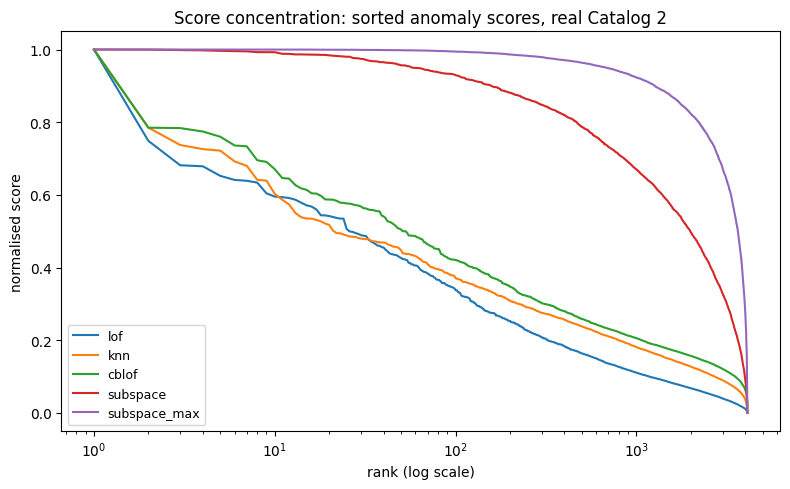

Tail prominence (score at rank 20 / median score), higher = more separated tail:
  lof            1.71
  knn            2.76
  cblof          3.37
  subspace       1.98
  subspace_max   1.20


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for m in METHODS:
    s = np.sort(scores[m].values)[::-1]
    s_norm = (s - s.min()) / (s.max() - s.min())
    ax.plot(np.arange(1, len(s) + 1), s_norm, label=m)
ax.set_xscale('log')
ax.set_xlabel('rank (log scale)')
ax.set_ylabel('normalised score')
ax.set_title('Score concentration: sorted anomaly scores, real Catalog 2')
ax.legend(fontsize=9)
plt.tight_layout()
fig_path = PROJECT / 'reports' / 'Phase 1' / 'figures' / 'candidate_score_concentration.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print('Tail prominence (score at rank 20 / median score), higher = more separated tail:')
for m in METHODS:
    s = scores[m].values
    rank20 = np.sort(s)[::-1][19]
    print(f'  {m:14s} {rank20 / np.median(s):.2f}')

## Diagnostic 2: stability across random seeds

The sharpest test of the trigger-happy concern. subspace_max is re-scored under several seeds
(each draws a different set of 20 random subspaces); the top-20 real bursts under each seed are
compared by mean pairwise Jaccard overlap. A signal-driven detector flags the same bursts
regardless of which subspaces it happens to draw (high overlap, near 1). A noise-driven one
flags a different set each time (low overlap, near 0). The mean-aggregated subspace is shown
for contrast; LOF is deterministic and trivially stable (overlap 1.0), included as the
reference ceiling.

In [5]:
def top_set(s, k=20):
    return set(np.argsort(s)[::-1][:k])


def mean_jaccard(sets):
    pairs = [(i, j) for i in range(len(sets)) for j in range(i + 1, len(sets))]
    return np.mean([len(sets[i] & sets[j]) / len(sets[i] | sets[j]) for i, j in pairs])

SEEDS = list(range(8))
max_sets  = [top_set(subspace_scores(X, seed=s, agg='max'))  for s in SEEDS]
mean_sets = [top_set(subspace_scores(X, seed=s, agg='mean')) for s in SEEDS]

print(f'Top-20 stability across {len(SEEDS)} seeds (mean pairwise Jaccard, 1.0 = identical):')
print(f'  subspace_max   {mean_jaccard(max_sets):.2f}')
print(f'  subspace(mean) {mean_jaccard(mean_sets):.2f}')
print(f'  lof            1.00   (deterministic reference)')

union_max = set().union(*max_sets)
print(f'\nsubspace_max: {len(union_max)} distinct bursts appear across the {len(SEEDS)} seeds\' '
      f'top-20 (20 = perfectly stable, 160 = completely unstable).')

Top-20 stability across 8 seeds (mean pairwise Jaccard, 1.0 = identical):
  subspace_max   0.52
  subspace(mean) 0.63
  lof            1.00   (deterministic reference)

subspace_max: 43 distinct bursts appear across the 8 seeds' top-20 (20 = perfectly stable, 160 = completely unstable).


## Diagnostic 3: cross-method agreement and the candidate shortlist

A real burst flagged in the top tier by several methods of different inductive bias is a robust
candidate. The shortlist is built only from the methods that passed the specificity diagnostics
above and are mutually independent: LOF, kNN and CBLOF. Both subspace aggregations are excluded,
because subspace_max failed concentration and stability, and because subspace and subspace_max
are two views of the same ensemble and would double-count. A burst in the top 1% of at least two
of the three is kept, ordered by how many agree.

In [6]:
# The shortlist uses only the independent, specificity-passing methods (LOF, kNN, CBLOF). The
# two subspace aggregations are excluded: subspace_max failed the diagnostics above, and the two
# are not independent of each other.
STABLE_METHODS = ['lof', 'knn', 'cblof']
TOP_FRAC = 0.01
top_k = max(1, int(round(TOP_FRAC * len(scores))))
flags = pd.DataFrame({m: scores[m + '_rank'] <= top_k for m in STABLE_METHODS})
n_methods = flags.sum(axis=1)

shortlist_idx = n_methods[n_methods >= 2].sort_values(ascending=False).index
shortlist = ids.loc[shortlist_idx].copy()
shortlist['n_methods'] = n_methods.loc[shortlist_idx].values
for m in STABLE_METHODS:
    shortlist[m] = flags.loc[shortlist_idx, m].values

print(f'Robust candidates (top {TOP_FRAC:.0%} of >= 2 of {STABLE_METHODS}): {len(shortlist)} bursts')
print(shortlist.to_string(index=False))

out = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_candidate_shortlist.csv'
shortlist.to_csv(out, index=False)
print(f'\nSaved shortlist to {out.relative_to(PROJECT)}')

Robust candidates (top 1% of >= 2 of ['lof', 'knn', 'cblof']): 36 bursts
    tns_name  sub_num  is_repeater  n_methods   lof   knn  cblof
FRB20201126C        0        False          3  True  True   True
FRB20200130B        0        False          3  True  True   True
FRB20221219D        0         True          3  True  True   True
FRB20220407A        0        False          3  True  True   True
FRB20211108A        1        False          3  True  True   True
FRB20210513C        0        False          3  True  True   True
FRB20210512C        0        False          3  True  True   True
FRB20210423B        0        False          3  True  True   True
FRB20210222C        0        False          3  True  True   True
FRB20200723B        0        False          3  True  True   True
FRB20200705D        0        False          3  True  True   True
FRB20200429A        0        False          3  True  True   True
FRB20230826A        1         True          3  True  True   True
FRB20200127A     

## Reading the result and next step

- If subspace_max shows a clear knee (Diagnostic 1) and high seed-stability (Diagnostic 2,
  overlap well above the bulk and comparable to the other methods), it discriminates rather
  than floods and is adopted for the real hunt.
- If it shows no knee and low stability, its injection-recovery sensitivity was a mirage; it is
  rejected and the detector falls back to CBLOF plus LOF/kNN.
- Either way the cross-method shortlist (Diagnostic 3) is the candidate set of weird FRBs.

Next: artifact rejection on the shortlist, removing bursts whose ranking is driven by
unconstrained fits or quality issues, using the raw catalogue fit-error columns and quality
flags (excluded_flag, sidelobe_flag, intrachan_flag), not the scaled features. The surviving
bursts are the reported answer to whether morphologically anomalous FRBs exist in the Catalog 2
tabulated parameters.